In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import natsort

In [44]:
files = glob.glob("../output/*/wat_300_npt_density.csv")
files = natsort.natsorted(files)

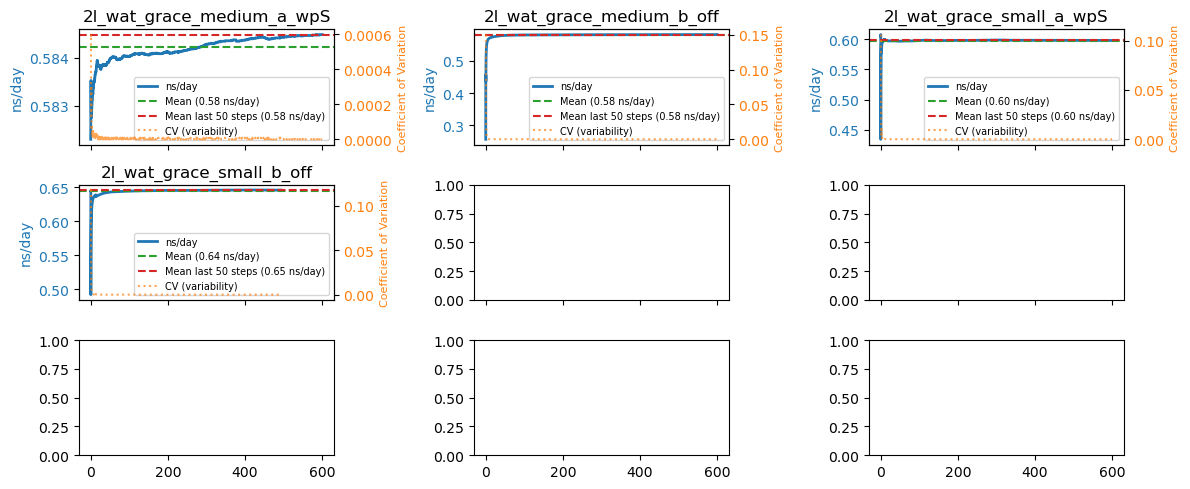

In [45]:
fig, axes = plt.subplots(3, 3, figsize=(12, 5), sharey=False, sharex=True)
axes = axes.flatten()

window_size = 10

for i, file in enumerate(files):
    data = pd.read_csv(file)
    data = data
    # Calculate coefficient of variation for variability
    rolling_mean = data["ns_per_day"].rolling(window=window_size).mean()
    rolling_std = data["ns_per_day"].rolling(window=window_size).std()
    cv = rolling_std / rolling_mean

    # Primary y-axis (speed)
    axes[i].plot(
        data["time_ps"], data["ns_per_day"], linewidth=2, label="ns/day", color="C0"
    )
    axes[i].axhline(
        data["ns_per_day"].mean(),
        color="C2",
        linestyle="--",
        label=f'Mean ({data["ns_per_day"].mean():.2f} ns/day)',
    )
    axes[i].axhline(
        data["ns_per_day"][-20:].mean(),
        color="C3",
        linestyle="--",
        label=f'Mean last 50 steps ({data["ns_per_day"][-50:].mean():.2f} ns/day)',
    )
    axes[i].set_ylabel("ns/day", color="C0")
    axes[i].tick_params(axis="y", labelcolor="C0")

    # Secondary y-axis (variability)
    ax2 = axes[i].twinx()
    ax2.plot(
        data["time_ps"],
        cv,
        linewidth=1.5,
        alpha=0.7,
        label="CV (variability)",
        color="C1",
        linestyle=":",
    )
    # ax2.axhline(0.1, color='orange', linestyle='--', linewidth=1.5, alpha=0.8, label='CV threshold (10%)')
    ax2.set_ylabel("Coefficient of Variation", color="C1", fontsize=8)
    ax2.tick_params(axis="y", labelcolor="C1")

    axes[i].set_title(f"{file.split('/')[-2]}")

    # Combine legends from both axes
    lines1, labels1 = axes[i].get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    axes[i].legend(lines1 + lines2, labels1 + labels2, fontsize=7, loc="best")

plt.tight_layout()
plt.show()

In [46]:
# Performance data for different GPUs
performance_data = {
    'L40s': {
        'mace-small': {'float32': 1.21, 'float64': 0.36},
        '1L-small': {'float32': 1.53, 'float64': 1.23},
        '1L-medium': {'float32': 1.24, 'float64': 0.92},
        '1L-large': {'float32': 1.26, 'float64': 0.82},
        '2L-small': {'float32': 1.28, 'float64': 0.84},
        '2L-medium': {'float32': 1.15, 'float64': 0.68},
        '2L-large': {'float32': 0.89, 'float64': 0.53},
    },
    'A100s': {
        'mace-small': {'float32': 0.87, 'float64': 0.8},
        '1L-small': {'float32': 0.95, 'float64': 0.67},
        '1L-medium': {'float32': 0.62, 'float64': 0.57},
        '1L-large': {'float32': 0.68, 'float64': 0.59},
        '2L-small': {'float32': 0.62, 'float64': 0.56},
        '2L-medium': {'float32': 0.61, 'float64': 0.56},
        '2L-large': {'float32': 0.54, 'float64': 0.44},
    }
}

# Display the dictionary
performance_data

{'L40s': {'mace-small': {'float32': 1.21, 'float64': 0.36},
  '1L-small': {'float32': 1.53, 'float64': 1.23},
  '1L-medium': {'float32': 1.24, 'float64': 0.92},
  '1L-large': {'float32': 1.26, 'float64': 0.82},
  '2L-small': {'float32': 1.28, 'float64': 0.84},
  '2L-medium': {'float32': 1.15, 'float64': 0.68},
  '2L-large': {'float32': 0.89, 'float64': 0.53}},
 'A100s': {'mace-small': {'float32': 0.87, 'float64': 0.8},
  '1L-small': {'float32': 0.95, 'float64': 0.67},
  '1L-medium': {'float32': 0.62, 'float64': 0.57},
  '1L-large': {'float32': 0.68, 'float64': 0.59},
  '2L-small': {'float32': 0.62, 'float64': 0.56},
  '2L-medium': {'float32': 0.61, 'float64': 0.56},
  '2L-large': {'float32': 0.54, 'float64': 0.44}}}

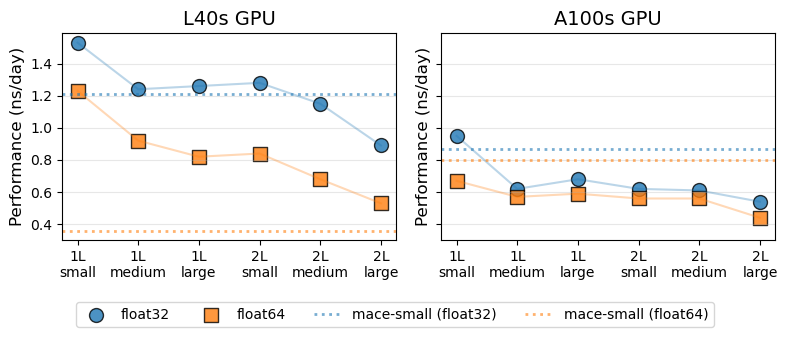

In [47]:
# Create side-by-side comparison of both GPUs
fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharey=True)

for idx, gpu_name in enumerate(['L40s', 'A100s']):
    ax = axes[idx]
    
    # Extract data for plotting (exclude mace-small from scatter plot)
    models = [m for m in performance_data[gpu_name].keys() if m != 'mace-small']
    float32_values = [performance_data[gpu_name][model]["float32"] for model in models]
    float64_values = [performance_data[gpu_name][model]["float64"] for model in models]
    
    x = np.arange(len(models))
    
    # Create scatter plot with connecting lines for float32
    # Filter out None values for float32
    x_float32 = [i for i, val in enumerate(float32_values) if val is not None]
    y_float32 = [val for val in float32_values if val is not None]
    ax.plot(x_float32, y_float32, color="C0", alpha=0.3, linewidth=1.5, linestyle="-")
    ax.scatter(
        x_float32,
        y_float32,
        s=100,
        label="float32",
        alpha=0.8,
        color="C0",
        marker="o",
        edgecolors="black",
        linewidths=1,
    )
    
    # Create scatter plot with connecting lines for float64
    # Filter out None values for float64
    x_float64 = [i for i, val in enumerate(float64_values) if val is not None]
    y_float64 = [val for val in float64_values if val is not None]
    ax.plot(x_float64, y_float64, color="C1", alpha=0.3, linewidth=1.5, linestyle="-")
    ax.scatter(
        x_float64,
        y_float64,
        s=100,
        label="float64",
        alpha=0.8,
        color="C1",
        marker="s",
        edgecolors="black",
        linewidths=1,
    )
    
    # Add reference lines for mace-small
    mace_small_float32 = performance_data[gpu_name]['mace-small']['float32']
    mace_small_float64 = performance_data[gpu_name]['mace-small']['float64']
    if mace_small_float32 is not None:
        ax.axhline(
            mace_small_float32,
            color="C0",
            linestyle=":",
            linewidth=2,
            alpha=0.6,
            label=f"mace-small (float32)",
        )
    if mace_small_float64 is not None:
        ax.axhline(
            mace_small_float64,
            color="C1",
            linestyle=":",
            linewidth=2,
            alpha=0.6,
            label=f"mace-small (float64)",
        )
    
    # Format model names with line breaks
    model_labels = []
    for model in models:
        if "-" in model:
            parts = model.rsplit("-", 1)  # Split on last hyphen
            model_labels.append(f"{parts[0]}\n{parts[1]}")
        else:
            model_labels.append(model)
    
    # Customize the plot
    ax.set_ylabel("Performance (ns/day)", fontsize=12)
    ax.set_title(f"{gpu_name} GPU", fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(model_labels, ha="center")
    ax.grid(True, alpha=0.3, axis="y")

# Add a single legend below both plots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.0), ncol=4, frameon=True)

plt.tight_layout()
plt.show()

In [48]:
# Dictionary containing all properties for different models
properties_data = {
    'Experiment': {
        'Heat capacity (cal/K/mol)': 1.0,
        'Isothermal compressibility (*1e4/bar)': 0.45,
        'Thermal expansion (*1e2/K)': 0.03,
        'Heat of vaporization (kJ/mol)': 43.99,
        'Density (g/mL)': 0.997,
    },
    'mace\nsmall': {
        'Heat capacity (cal/K/mol)': 1.64,
        'Isothermal compressibility (*1e4/bar)': 0.26,
        'Thermal expansion (*1e2/K)': 0.09,
        'Heat of vaporization (kJ/mol)': 47.79,
        'Density (g/mL)': 1.12,
    },
    'mace\nmedium': {
        'Heat capacity (cal/K/mol)': 1.52,
        'Isothermal compressibility (*1e4/bar)': 0.23,
        'Thermal expansion (*1e2/K)': 0.09,
        'Heat of vaporization (kJ/mol)': 48.90,
        'Density (g/mL)': 1.18,
    },
    '2L small\na_wpS': {
        'Heat capacity (cal/K/mol)': 1.73,
        'Isothermal compressibility (*1e4/bar)': 0.36,
        'Thermal expansion (*1e2/K)': 0.04,
        'Heat of vaporization (kJ/mol)': 44.25,
        'Density (g/mL)': 1.11,
    },
    '2L medium\na_wpS': {
        'Heat capacity (cal/K/mol)': 1.88,
        'Isothermal compressibility (*1e4/bar)': 0.05,
        'Thermal expansion (*1e2/K)': -0.0,
        'Heat of vaporization (kJ/mol)': 49.7,
        'Density (g/mL)': 0.99,
    },
    '2L small\nb_off': {
        'Heat capacity (cal/K/mol)': 1.97,
        'Isothermal compressibility (*1e4/bar)': 0.43,
        'Thermal expansion (*1e2/K)': 0.06,
        'Heat of vaporization (kJ/mol)': 42.55,
        'Density (g/mL)': 1.01,
    },
    '2L medium\nb_off': {
        'Heat capacity (cal/K/mol)': 1.9,
        'Isothermal compressibility (*1e4/bar)': 0.42,
        'Thermal expansion (*1e2/K)': 0.02,
        'Heat of vaporization (kJ/mol)': 43.38,
        'Density (g/mL)': 0.99,
    },
}


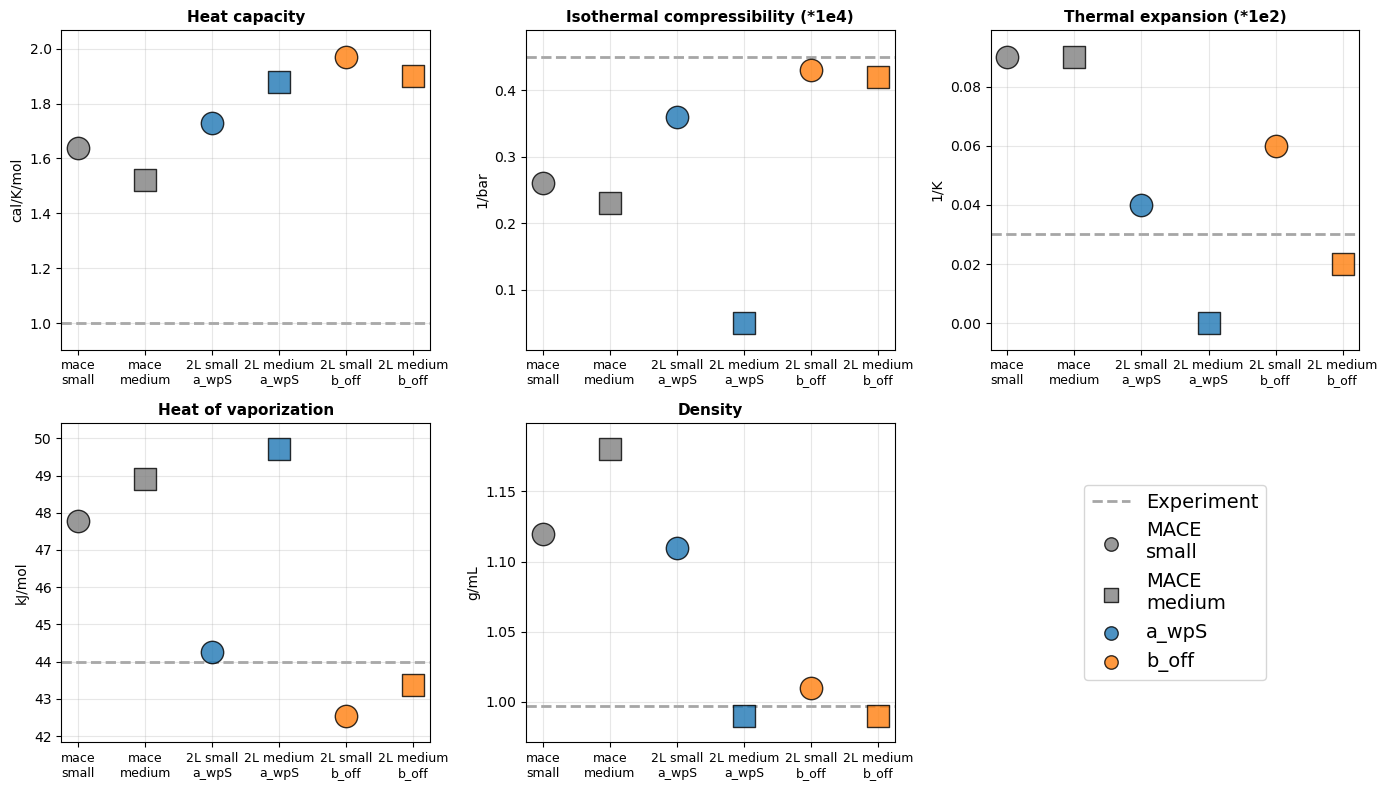

In [49]:
# Create subplots for each property
properties_config = [
    {'name': 'Heat capacity', 'unit': 'cal/K/mol'},
    {'name': 'Isothermal compressibility (*1e4)', 'unit': '1/bar'},
    {'name': 'Thermal expansion (*1e2)', 'unit': '1/K'},
    {'name': 'Heat of vaporization', 'unit': 'kJ/mol'},
    {'name': 'Density', 'unit': 'g/mL'}
]

# Original property keys for data access
properties = [
    'Heat capacity (cal/K/mol)',
    'Isothermal compressibility (*1e4/bar)',
    'Thermal expansion (*1e2/K)',
    'Heat of vaporization (kJ/mol)',
    'Density (g/mL)'
]

# Extract model names (excluding Experiment)
models = [model for model in properties_data.keys() if model != 'Experiment']

# Define colors and markers based on model type
def get_color_and_marker(model_name):
    if 'mace' in model_name.lower() and 'small' in model_name.lower():
        return 'grey', 'o', 'MACE\nsmall'  # Black color, circle marker for MACE small
    elif 'mace' in model_name.lower() and 'medium' in model_name.lower():
        return 'grey', 's', 'MACE\nmedium'  # Black color, square marker for MACE medium
    elif 'a_wpS' in model_name:
        # Determine size for marker
        if 'small' in model_name.lower():
            return 'C0', 'o', 'a_wpS'  # Blue for a_wpS models, circle for small
        else:
            return 'C0', 's', 'a_wpS'  # Blue for a_wpS models, square for medium
    elif 'b_off' in model_name:
        # Determine size for marker
        if 'small' in model_name.lower():
            return 'C1', 'o', 'b_off'  # Orange for b_off models, circle for small
        else:
            return 'C1', 's', 'b_off'  # Orange for b_off models, square for medium
    else:
        return 'C2', 'o', 'mace'  # Default to mace

# Create figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

# Track which labels we've already added to avoid duplicates
added_labels = set()

for i, (prop, config) in enumerate(zip(properties, properties_config)):
    ax = axes[i]
    
    # Get experimental value for horizontal line
    exp_value = properties_data['Experiment'][prop]
    
    # Get values for each model
    values = [properties_data[model][prop] for model in models]
    
    # Create x-axis positions
    x = np.arange(len(models))
    
    # Plot experimental reference line (only add label once)
    if 'Experiment' not in added_labels:
        ax.axhline(exp_value, color='gray', linestyle='--', linewidth=2, 
                   label='Experiment', alpha=0.7, zorder=1)
        added_labels.add('Experiment')
    else:
        ax.axhline(exp_value, color='gray', linestyle='--', linewidth=2, 
                   alpha=0.7, zorder=1)
    
    # Plot scatter points for models with different colors and markers
    for j, (model, value) in enumerate(zip(models, values)):
        color, marker, label = get_color_and_marker(model)
        
        # Only add label if not already added
        if label not in added_labels:
            ax.scatter(j, value, s=260, alpha=0.8, color=color, 
                       marker=marker, edgecolors='black', linewidths=1, 
                       zorder=3, label=label)
            added_labels.add(label)
        else:
            ax.scatter(j, value, s=260, alpha=0.8, color=color, 
                       marker=marker, edgecolors='black', linewidths=1, zorder=3)
    
    # Customize plot
    ax.set_title(config['name'], fontsize=11, fontweight='bold')
    ax.set_ylabel(config['unit'], fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=0, ha='center', fontsize=9)
    ax.grid(True, alpha=0.3, axis='both')
    
    # Add slight padding to y-axis
    y_min = min(min(values), exp_value)
    y_max = max(max(values), exp_value)
    y_range = y_max - y_min
    ax.set_ylim(y_min - 0.1*y_range, y_max + 0.1*y_range)

# Use the 6th subplot position for the legend
axes[5].axis('off')  # Turn off the axis
handles, labels = axes[0].get_legend_handles_labels()
axes[5].legend(handles, labels, loc='center', fontsize=14, frameon=True, markerscale=0.6)

plt.tight_layout()
plt.show()
